In [30]:
# If needed:
# !pip install -q pydicom SimpleITK opencv-python pandas numpy matplotlib tqdm

In [31]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import cv2
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm
import matplotlib.pyplot as plt

In [32]:
INPUT_JSON = Path("../Class_Making/out/dataset_target_class.json")
INPUT_CSV = Path("../Class_Making/out/dataset_target_class.csv")  # optional helper for ordering/checks

OUT_DIR = Path("out/preprocessed_xy1_crop224_target_class")
CROP_SIZE = 224
TARGET_SPACING_X = 1.0
TARGET_SPACING_Y = 1.0
HU_MIN = -700.0
HU_MAX = 200.0

OUT_IMAGES_DIR = OUT_DIR / "images"
OUT_MASKS_DIR = OUT_DIR / "masks"
OUT_VIS_DIR = OUT_DIR / "visual_checks"

for d in [OUT_DIR, OUT_IMAGES_DIR, OUT_MASKS_DIR, OUT_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("INPUT_JSON:", INPUT_JSON.resolve())
print("INPUT_CSV :", INPUT_CSV.resolve())
print("OUT_DIR   :", OUT_DIR.resolve())
AUGMENT_MALIGNANT = True
AUG_TARGET_FRACTIONS = [1/3, 1/2, 2/3]   # desired nodule center fractions inside 224x224 crop
MAX_AUGS_PER_IMAGE = 2                    # cap newly created crops per malignant image
MIN_MASK_PIXELS_IN_AUG = 1                # keep only if cropped mask remains non-empty


INPUT_JSON: C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\Thesis_Coding_revised\Class_Making\out\dataset_target_class.json
INPUT_CSV : C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\Thesis_Coding_revised\Class_Making\out\dataset_target_class.csv
OUT_DIR   : C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\Thesis_Coding_revised\Preprocessing_2\out\preprocessed_xy1_crop224_target_class


In [33]:
if not INPUT_JSON.exists():
    raise FileNotFoundError(f"Could not find input JSON: {INPUT_JSON}")

data = json.loads(INPUT_JSON.read_text(encoding="utf-8"))

# Support both:
# 1) {"images": {...}, ...}
# 2) {image_id: {...}, ...}
# 3) [ {...}, {...} ]
if isinstance(data, dict) and "images" in data and isinstance(data["images"], dict):
    images_dict = data["images"]
    input_json_style = "dict_with_images_key"
elif isinstance(data, dict):
    images_dict = {k: v for k, v in data.items() if isinstance(v, dict)}
    input_json_style = "dict_records"
elif isinstance(data, list):
    images_dict = {}
    for item in data:
        if isinstance(item, dict) and "image_id" in item:
            images_dict[item["image_id"]] = item
    input_json_style = "list_records"
else:
    raise ValueError("Unsupported JSON structure.")

print("Input JSON style:", input_json_style)
print("Selected image count from JSON:", len(images_dict))

input_df = None
if INPUT_CSV.exists():
    input_df = pd.read_csv(INPUT_CSV)
    print("Input CSV rows:", len(input_df))
else:
    print("Input CSV not found. JSON order will be used.")


Input JSON style: dict_with_images_key
Selected image count from JSON: 2385
Input CSV rows: 2385


In [34]:
def read_dicom_hu(dicom_path: str | Path) -> tuple[np.ndarray, float, float, dict]:
    ds = pydicom.dcmread(str(dicom_path))
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    hu = img * slope + intercept

    spacing = getattr(ds, "PixelSpacing", None)
    if spacing is None or len(spacing) < 2:
        raise ValueError(f"PixelSpacing missing in DICOM: {dicom_path}")

    # DICOM PixelSpacing = [row_spacing (y), col_spacing (x)]
    sy = float(spacing[0])
    sx = float(spacing[1])

    meta = {
        "slope": slope,
        "intercept": intercept,
        "spacing_y": sy,
        "spacing_x": sx,
        "rows": int(getattr(ds, "Rows", hu.shape[0])),
        "cols": int(getattr(ds, "Columns", hu.shape[1])),
    }
    return hu, sx, sy, meta


def clip_and_normalize_hu(img_hu: np.ndarray,
                          hu_min: float = HU_MIN,
                          hu_max: float = HU_MAX) -> np.ndarray:
    img = np.clip(img_hu, hu_min, hu_max)
    img = (img - hu_min) / (hu_max - hu_min)
    return img.astype(np.float32)


def resample_xy_image(img: np.ndarray,
                      spacing_x: float,
                      spacing_y: float,
                      target_spacing_x: float = TARGET_SPACING_X,
                      target_spacing_y: float = TARGET_SPACING_Y,
                      interpolation: int = cv2.INTER_LINEAR) -> tuple[np.ndarray, float, float]:
    h, w = img.shape[:2]
    new_w = max(1, int(round(w * spacing_x / target_spacing_x)))
    new_h = max(1, int(round(h * spacing_y / target_spacing_y)))
    resampled = cv2.resize(img, (new_w, new_h), interpolation=interpolation)
    return resampled, float(target_spacing_x), float(target_spacing_y)


def scale_polygon_xy(points,
                     spacing_x: float,
                     spacing_y: float,
                     target_spacing_x: float = TARGET_SPACING_X,
                     target_spacing_y: float = TARGET_SPACING_Y) -> np.ndarray:
    pts = np.array(points, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 2:
        raise ValueError("Polygon points must be Nx2.")
    pts[:, 0] = pts[:, 0] * (spacing_x / target_spacing_x)
    pts[:, 1] = pts[:, 1] * (spacing_y / target_spacing_y)
    return pts


def rasterize_polygons(polygons_xy: list[np.ndarray], shape_hw: tuple[int, int]) -> np.ndarray:
    mask = np.zeros(shape_hw, dtype=np.uint8)
    for pts in polygons_xy:
        if pts is None or len(pts) < 3:
            continue
        pts_int = np.round(pts).astype(np.int32)
        cv2.fillPoly(mask, [pts_int], 1)
    return mask


def mask_centroid(mask: np.ndarray) -> tuple[float, float] | None:
    m = cv2.moments(mask.astype(np.uint8))
    if m["m00"] == 0:
        return None
    cx = float(m["m10"] / m["m00"])
    cy = float(m["m01"] / m["m00"])
    return cx, cy


def safe_crop_window(cx: float, cy: float, width: int, height: int, crop_size: int = CROP_SIZE) -> tuple[int, int, int, int]:
    if width < crop_size or height < crop_size:
        raise ValueError(
            f"Image is smaller than crop size after resampling: image=({height}, {width}), crop={crop_size}"
        )

    half = crop_size // 2
    x1 = int(round(cx)) - half
    y1 = int(round(cy)) - half

    x1 = max(0, min(x1, width - crop_size))
    y1 = max(0, min(y1, height - crop_size))

    x2 = x1 + crop_size
    y2 = y1 + crop_size
    return x1, y1, x2, y2


def extract_contours_from_mask(mask: np.ndarray) -> list[list[list[int]]]:
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in contours:
        c = c.squeeze()
        if c.ndim == 2 and len(c) >= 3:
            polys.append(c.astype(int).tolist())
    return polys


def polygon_center_from_mask(mask: np.ndarray) -> tuple[float, float]:
    centroid = mask_centroid(mask)
    if centroid is None:
        ys, xs = np.where(mask > 0)
        if len(xs) == 0:
            raise ValueError("Empty mask. Cannot compute center.")
        return float(xs.mean()), float(ys.mean())
    return centroid


def point_or_polygon_center(mark: dict, spacing_x: float, spacing_y: float) -> tuple[float, float]:
    shape_type = mark.get("shape_type")
    if shape_type == "point":
        x, y = mark["locus"]
        return (
            float(x) * (spacing_x / TARGET_SPACING_X),
            float(y) * (spacing_y / TARGET_SPACING_Y),
        )
    elif shape_type == "polygon":
        pts = scale_polygon_xy(mark["polygon"], spacing_x, spacing_y)
        mask = rasterize_polygons([pts], shape_hw=(int(np.ceil(pts[:,1].max())) + 5, int(np.ceil(pts[:,0].max())) + 5))
        center = mask_centroid(mask)
        if center is None:
            return float(pts[:, 0].mean()), float(pts[:, 1].mean())
        return center[0], center[1]
    else:
        raise ValueError(f"Unsupported non-nodule shape_type: {shape_type}")


def choose_largest_nodule(consensus_nodules: list[dict], shape_hw: tuple[int, int], spacing_x: float, spacing_y: float) -> tuple[dict, tuple[float, float], list[dict]]:
    if not consensus_nodules:
        raise ValueError("Positive sample has no consensus nodules.")

    prepared = []
    for n in consensus_nodules:
        scaled_polys = [scale_polygon_xy(poly, spacing_x, spacing_y) for poly in n.get("polygons", [])]
        n_mask = rasterize_polygons(scaled_polys, shape_hw=shape_hw)
        area = int(n_mask.sum())
        prepared.append({
            "consensus_id": n.get("consensus_id"),
            "malignancy_array": list(n.get("malignancy_array", [])),
            "scaled_polygons": scaled_polys,
            "mask": n_mask,
            "area": area,
        })

    prepared_sorted = sorted(prepared, key=lambda x: x["area"], reverse=True)
    largest = prepared_sorted[0]
    center = polygon_center_from_mask(largest["mask"])
    return largest, center, prepared_sorted


def save_npy(path: Path, arr: np.ndarray) -> str:
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, arr)
    return str(path)

In [35]:

def is_malignant_case(entry: dict) -> bool:
    tc = str(entry.get("target_class", "")).strip().lower()
    if "malig" in tc:
        return True
    # optional fallback for common encodings
    tci = entry.get("target_class_id")
    if tc == "" and tci in (1, 2):
        return True
    return False


def build_records_for_crop(
    *,
    image_id: str,
    entry: dict,
    dicom_path: str,
    sample_type: str,
    target_class,
    target_class_id,
    malignancy_avg,
    sx: float,
    sy: float,
    img_hu: np.ndarray,
    img_xy1: np.ndarray,
    combined_mask_full: np.ndarray,
    crop_center_x: float,
    crop_center_y: float,
    x1: int,
    y1: int,
    x2: int,
    y2: int,
    out_images_dir: Path,
    out_masks_dir: Path,
    prepared_nodules: list[dict],
    largest_consensus_id,
    largest_consensus_area_resampled,
    selected_non_nodule_index,
    negative_center_source: str,
) -> tuple[dict, dict]:
    H, W = img_xy1.shape

    cropped_img = img_xy1[y1:y2, x1:x2]
    if cropped_img.shape != (CROP_SIZE, CROP_SIZE):
        raise ValueError(f"Bad crop shape for {image_id}: {cropped_img.shape}")

    cropped_mask = None
    if sample_type == "pos":
        cropped_mask = combined_mask_full[y1:y2, x1:x2]
        if cropped_mask.shape != (CROP_SIZE, CROP_SIZE):
            raise ValueError(f"Bad mask crop shape for {image_id}: {cropped_mask.shape}")
        if int(cropped_mask.sum()) < MIN_MASK_PIXELS_IN_AUG:
            raise ValueError(f"Positive sample {image_id} produced an empty cropped mask.")

    image_path = out_images_dir / f"{image_id}.npy"
    image_path_str = save_npy(image_path, cropped_img.astype(np.float32))

    mask_path_str = ""
    if cropped_mask is not None:
        mask_path = out_masks_dir / f"{image_id}_mask.npy"
        mask_path_str = save_npy(mask_path, cropped_mask.astype(np.uint8))

    cropped_nodule_records = []
    if sample_type == "pos":
        for n in prepared_nodules:
            n_crop = n["mask"][y1:y2, x1:x2]
            polys_crop = extract_contours_from_mask(n_crop)
            cropped_nodule_records.append({
                "consensus_id": n["consensus_id"],
                "malignancy_array": list(n["malignancy_array"]),
                "resampled_area": int(n["area"]),
                "cropped_area": int(n_crop.sum()),
                "cropped_polygons": polys_crop,
            })

    csv_row = {
        "image_id": image_id,
        "patient_id": entry.get("patient_id"),
        "slice_index": int(entry.get("slice_index")) if entry.get("slice_index") is not None else None,
        "z_position": float(entry.get("z_position")) if entry.get("z_position") is not None else None,
        "sample_type": sample_type,
        "target_class": target_class,
        "target_class_id": target_class_id,
        "malignancy_avg": malignancy_avg,
        "class_id": int(1 if sample_type == "pos" else 0),
        "has_nodule": int(1 if sample_type == "pos" else 0),
        "dicom_path": dicom_path,
        "sop_instance_uid": entry.get("sop_instance_uid"),
        "image_path": image_path_str,
        "mask_path": mask_path_str,
        "largest_consensus_id_for_center": largest_consensus_id,
        "largest_consensus_area_resampled": largest_consensus_area_resampled,
        "selected_non_nodule_index": selected_non_nodule_index,
        "negative_center_source": negative_center_source,
        "crop_center_x_resampled": float(crop_center_x),
        "crop_center_y_resampled": float(crop_center_y),
        "crop_x1": int(x1),
        "crop_y1": int(y1),
        "crop_x2": int(x2),
        "crop_y2": int(y2),
        "crop_size": int(CROP_SIZE),
        "original_spacing_x": float(sx),
        "original_spacing_y": float(sy),
        "target_spacing_x": float(TARGET_SPACING_X),
        "target_spacing_y": float(TARGET_SPACING_Y),
        "original_height": int(img_hu.shape[0]),
        "original_width": int(img_hu.shape[1]),
        "resampled_height": int(H),
        "resampled_width": int(W),
        "hu_min": float(HU_MIN),
        "hu_max": float(HU_MAX),
        "normalization": "minmax_after_hu_window_to_[0,1]",
        "num_consensus_nodules_original": int(len(entry.get("consensus_nodules", []))),
        "num_consensus_nodules_in_crop": int(sum(1 for n in cropped_nodule_records if n["cropped_area"] > 0)),
        "malignancy_max": (
            int(max(max(n["malignancy_array"]) for n in cropped_nodule_records if len(n["malignancy_array"]) > 0))
            if cropped_nodule_records else None
        ),
        "processing_status": "ok",
        "error_message": "",
    }

    json_row = dict(csv_row)
    if sample_type == "pos":
        json_row["consensus_nodules_cropped"] = cropped_nodule_records
    else:
        json_row["consensus_nodules_cropped"] = []
    return csv_row, json_row


def generate_malignant_aug_windows(
    crop_center_x: float,
    crop_center_y: float,
    width: int,
    height: int,
) -> list[tuple[int, int, int, int, int, int]]:
    """Return distinct safe crop windows for malignant augmentation.
    Each tuple: (x1, y1, x2, y2, tx, ty), where tx/ty describe center shift vs original center.
    """
    base_x1, base_y1, base_x2, base_y2 = safe_crop_window(crop_center_x, crop_center_y, width, height, crop_size=CROP_SIZE)
    base_key = (base_x1, base_y1, base_x2, base_y2)

    candidates = []
    seen = {base_key}

    for fy in AUG_TARGET_FRACTIONS:
        for fx in AUG_TARGET_FRACTIONS:
            target_local_x = fx * (CROP_SIZE - 1)
            target_local_y = fy * (CROP_SIZE - 1)
            desired_x1 = int(round(crop_center_x - target_local_x))
            desired_y1 = int(round(crop_center_y - target_local_y))

            x1 = max(0, min(desired_x1, width - CROP_SIZE))
            y1 = max(0, min(desired_y1, height - CROP_SIZE))
            x2 = x1 + CROP_SIZE
            y2 = y1 + CROP_SIZE

            key = (x1, y1, x2, y2)
            if key in seen:
                continue
            seen.add(key)

            actual_center_local_x = crop_center_x - x1
            actual_center_local_y = crop_center_y - y1
            tx = int(round(actual_center_local_x - (crop_center_x - base_x1)))
            ty = int(round(actual_center_local_y - (crop_center_y - base_y1)))
            candidates.append((x1, y1, x2, y2, tx, ty))

    # prefer windows that move the nodule farther from its original local position
    base_local_x = crop_center_x - base_x1
    base_local_y = crop_center_y - base_y1
    candidates.sort(
        key=lambda t: abs((crop_center_x - t[0]) - base_local_x) + abs((crop_center_y - t[1]) - base_local_y),
        reverse=True
    )
    return candidates[:MAX_AUGS_PER_IMAGE]


def preprocess_one_entry(image_id: str, entry: dict, out_images_dir: Path, out_masks_dir: Path) -> list[tuple[dict, dict]]:
    dicom_path = entry["dicom_path"]
    sample_type = entry["sample_type"]  # pos / hard_neg / neg

    target_class = entry.get("target_class")
    target_class_id = entry.get("target_class_id")
    malignancy_avg = entry.get("malignancy_avg")

    img_hu, sx, sy, dicom_meta = read_dicom_hu(dicom_path)
    img_norm = clip_and_normalize_hu(img_hu, HU_MIN, HU_MAX)
    img_xy1, _, _ = resample_xy_image(
        img_norm, sx, sy,
        target_spacing_x=TARGET_SPACING_X,
        target_spacing_y=TARGET_SPACING_Y,
        interpolation=cv2.INTER_LINEAR
    )
    H, W = img_xy1.shape

    crop_center_x = None
    crop_center_y = None
    selected_non_nodule_index = None
    largest_consensus_id = None
    largest_consensus_area_resampled = None
    negative_center_source = ""

    combined_mask_full = np.zeros((H, W), dtype=np.uint8)

    if H < CROP_SIZE or W < CROP_SIZE:
        raise ValueError(f"Resampled image smaller than crop size for {image_id}: {(H, W)}")

    if sample_type == "pos":
        largest, (crop_center_x, crop_center_y), prepared_nodules = choose_largest_nodule(
            entry.get("consensus_nodules", []), shape_hw=(H, W), spacing_x=sx, spacing_y=sy
        )
        largest_consensus_id = largest["consensus_id"]
        largest_consensus_area_resampled = int(largest["area"])

        for n in prepared_nodules:
            combined_mask_full = np.maximum(combined_mask_full, n["mask"])
    else:
        marks = entry.get("non_nodule_marks", []) or []
        if marks:
            selected_non_nodule_index = 0
            crop_center_x, crop_center_y = point_or_polygon_center(marks[0], sx, sy)
            negative_center_source = "non_nodule_mark"
        else:
            crop_center_x = W / 2.0
            crop_center_y = H / 2.0
            negative_center_source = "image_center_fallback"
        prepared_nodules = []

    x1, y1, x2, y2 = safe_crop_window(crop_center_x, crop_center_y, W, H, crop_size=CROP_SIZE)

    all_records = []
    base_csv_row, base_json_row = build_records_for_crop(
        image_id=image_id,
        entry=entry,
        dicom_path=dicom_path,
        sample_type=sample_type,
        target_class=target_class,
        target_class_id=target_class_id,
        malignancy_avg=malignancy_avg,
        sx=sx,
        sy=sy,
        img_hu=img_hu,
        img_xy1=img_xy1,
        combined_mask_full=combined_mask_full,
        crop_center_x=crop_center_x,
        crop_center_y=crop_center_y,
        x1=x1, y1=y1, x2=x2, y2=y2,
        out_images_dir=out_images_dir,
        out_masks_dir=out_masks_dir,
        prepared_nodules=prepared_nodules,
        largest_consensus_id=largest_consensus_id,
        largest_consensus_area_resampled=largest_consensus_area_resampled,
        selected_non_nodule_index=selected_non_nodule_index,
        negative_center_source=negative_center_source,
    )
    all_records.append((base_csv_row, base_json_row))

    if AUGMENT_MALIGNANT and sample_type == "pos" and is_malignant_case(entry):
        aug_windows = generate_malignant_aug_windows(crop_center_x, crop_center_y, W, H)
        for ax1, ay1, ax2, ay2, tx, ty in aug_windows:
            aug_image_id = f"{image_id}__aug_tx_{tx:+d}_ty_{ty:+d}"
            try:
                aug_csv_row, aug_json_row = build_records_for_crop(
                    image_id=aug_image_id,
                    entry=entry,
                    dicom_path=dicom_path,
                    sample_type=sample_type,
                    target_class=target_class,
                    target_class_id=target_class_id,
                    malignancy_avg=malignancy_avg,
                    sx=sx,
                    sy=sy,
                    img_hu=img_hu,
                    img_xy1=img_xy1,
                    combined_mask_full=combined_mask_full,
                    crop_center_x=crop_center_x,
                    crop_center_y=crop_center_y,
                    x1=ax1, y1=ay1, x2=ax2, y2=ay2,
                    out_images_dir=out_images_dir,
                    out_masks_dir=out_masks_dir,
                    prepared_nodules=prepared_nodules,
                    largest_consensus_id=largest_consensus_id,
                    largest_consensus_area_resampled=largest_consensus_area_resampled,
                    selected_non_nodule_index=selected_non_nodule_index,
                    negative_center_source=negative_center_source,
                )
                all_records.append((aug_csv_row, aug_json_row))
            except Exception:
                # skip only the problematic augmented crop, keep the original sample
                continue

    return all_records


In [36]:

processed_csv_rows = []
processed_json_rows = {}
error_log = []

# Use CSV ordering if available, otherwise JSON ordering
if input_df is not None and "image_id" in input_df.columns:
    image_ids_to_process = [img_id for img_id in input_df["image_id"].tolist() if img_id in images_dict]
else:
    image_ids_to_process = list(images_dict.keys())

num_base_success = 0
num_augmented_success = 0

for image_id in tqdm(image_ids_to_process, total=len(image_ids_to_process), desc="Preprocessing"):
    entry = images_dict[image_id]
    try:
        records = preprocess_one_entry(image_id, entry, OUT_IMAGES_DIR, OUT_MASKS_DIR)
        for idx, (csv_row, json_row) in enumerate(records):
            processed_csv_rows.append(csv_row)
            processed_json_rows[csv_row["image_id"]] = json_row
            if idx == 0:
                num_base_success += 1
            else:
                num_augmented_success += 1
    except Exception as e:
        err_msg = str(e)
        error_log.append({
            "image_id": image_id,
            "patient_id": entry.get("patient_id"),
            "slice_index": entry.get("slice_index"),
            "sample_type": entry.get("sample_type"),
            "error": err_msg,
        })

        failed_csv_row = {
            "image_id": image_id,
            "patient_id": entry.get("patient_id"),
            "slice_index": int(entry.get("slice_index")) if entry.get("slice_index") is not None else None,
            "z_position": float(entry.get("z_position")) if entry.get("z_position") is not None else None,
            "sample_type": entry.get("sample_type"),
            "target_class": entry.get("target_class"),
            "target_class_id": entry.get("target_class_id"),
            "malignancy_avg": entry.get("malignancy_avg"),
            "class_id": int(1 if entry.get("sample_type") == "pos" else 0) if entry.get("sample_type") is not None else None,
            "has_nodule": int(1 if entry.get("sample_type") == "pos" else 0) if entry.get("sample_type") is not None else None,
            "dicom_path": entry.get("dicom_path", ""),
            "sop_instance_uid": entry.get("sop_instance_uid"),
            "image_path": "",
            "mask_path": "",
            "largest_consensus_id_for_center": None,
            "largest_consensus_area_resampled": None,
            "selected_non_nodule_index": None,
            "negative_center_source": "",
            "crop_center_x_resampled": None,
            "crop_center_y_resampled": None,
            "crop_x1": None,
            "crop_y1": None,
            "crop_x2": None,
            "crop_y2": None,
            "crop_size": int(CROP_SIZE),
            "original_spacing_x": None,
            "original_spacing_y": None,
            "target_spacing_x": float(TARGET_SPACING_X),
            "target_spacing_y": float(TARGET_SPACING_Y),
            "original_height": None,
            "original_width": None,
            "resampled_height": None,
            "resampled_width": None,
            "hu_min": float(HU_MIN),
            "hu_max": float(HU_MAX),
            "normalization": "minmax_after_hu_window_to_[0,1]",
            "num_consensus_nodules_original": int(len(entry.get("consensus_nodules", []))),
            "num_consensus_nodules_in_crop": None,
            "malignancy_max": (
                int(max(max(n.get("malignancy_array", [])) for n in entry.get("consensus_nodules", []) if n.get("malignancy_array")))
                if entry.get("consensus_nodules") else None
            ),
            "processing_status": "failed",
            "error_message": err_msg,
        }
        processed_csv_rows.append(failed_csv_row)

processed_df = pd.DataFrame(processed_csv_rows)

preferred_cols = [
    "image_id", "patient_id", "slice_index", "z_position",
    "sample_type", "target_class", "target_class_id", "malignancy_avg",
    "class_id", "has_nodule",
    "processing_status", "error_message",
    "dicom_path", "sop_instance_uid", "image_path", "mask_path",
    "largest_consensus_id_for_center", "largest_consensus_area_resampled", "selected_non_nodule_index", "negative_center_source",
    "crop_center_x_resampled", "crop_center_y_resampled",
    "crop_x1", "crop_y1", "crop_x2", "crop_y2", "crop_size",
    "original_spacing_x", "original_spacing_y", "target_spacing_x", "target_spacing_y",
    "original_height", "original_width", "resampled_height", "resampled_width",
    "hu_min", "hu_max", "normalization",
    "num_consensus_nodules_original", "num_consensus_nodules_in_crop", "malignancy_max",
]
processed_df = processed_df.reindex(columns=preferred_cols)

processed_csv_path = OUT_DIR / "processed_metadata_all_samples.csv"
processed_json_path = OUT_DIR / "processed_metadata_detailed.json"

processed_df.to_csv(processed_csv_path, index=False)

# Keep output JSON style similar to original notebook: top-level dict with images
processed_json_out = {
    "images": processed_json_rows
}
processed_json_path.write_text(json.dumps(processed_json_out, indent=2), encoding="utf-8")

print("Rows written to single CSV (successful + failed):", len(processed_df))
print("Successful original/base rows:", num_base_success)
print("Newly created malignant augmented rows:", num_augmented_success)
print("Successful cases total (base + aug):", int((processed_df["processing_status"] == "ok").sum()) if len(processed_df) else 0)
print("Failed base cases included in same CSV:", int((processed_df["processing_status"] == "failed").sum()) if len(processed_df) else 0)
print("Saved single CSV:", processed_csv_path)
print("Saved detailed JSON:", processed_json_path)

if len(processed_df):
    display(
        processed_df.groupby(["sample_type", "processing_status"]).size()
        .rename("count").reset_index()
    )
    display(processed_df.head(10))

    aug_mask = processed_df["image_id"].astype(str).str.contains("__aug_tx_", regex=False)
    print("\nBreakdown by original vs newly created rows:")
    display(
        pd.DataFrame({
            "row_type": ["original_or_base", "new_augmented"],
            "count": [int((~aug_mask & (processed_df["processing_status"] == "ok")).sum()), int((aug_mask & (processed_df["processing_status"] == "ok")).sum())]
        })
    )

if error_log:
    print("First few failed base rows included in the same CSV:")
    display(pd.DataFrame(error_log).head(10))


Preprocessing: 100%|██████████| 2385/2385 [00:22<00:00, 107.72it/s]


Rows written to single CSV (successful + failed): 3027
Successful original/base rows: 2385
Newly created malignant augmented rows: 642
Successful cases total (base + aug): 3027
Failed base cases included in same CSV: 0
Saved single CSV: out\preprocessed_xy1_crop224_target_class\processed_metadata_all_samples.csv
Saved detailed JSON: out\preprocessed_xy1_crop224_target_class\processed_metadata_detailed.json


,sample_type,processing_status,count
0,hard_neg,ok,881
1,neg,ok,912
2,pos,ok,1234


,image_id,patient_id,slice_index,z_position,sample_type,target_class,target_class_id,malignancy_avg,class_id,has_nodule,...,original_height,original_width,resampled_height,resampled_width,hu_min,hu_max,normalization,num_consensus_nodules_original,num_consensus_nodules_in_crop,malignancy_max
0,LIDC-IDRI-0001__slice_0020,LIDC-IDRI-0001,20,-290.0,neg,benign,0,NaN,0,0,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",0,0,NaN
1,LIDC-IDRI-0001__slice_0039,LIDC-IDRI-0001,39,-242.5,hard_neg,benign,0,NaN,0,0,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",0,0,NaN
2,LIDC-IDRI-0001__slice_0087,LIDC-IDRI-0001,87,-122.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0
3,LIDC-IDRI-0001__slice_0087__aug_tx_+37_ty_+26,LIDC-IDRI-0001,87,-122.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0
4,LIDC-IDRI-0001__slice_0087__aug_tx_-25_ty_+26,LIDC-IDRI-0001,87,-122.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0
5,LIDC-IDRI-0001__slice_0089,LIDC-IDRI-0001,89,-117.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0
6,LIDC-IDRI-0001__slice_0089__aug_tx_+36_ty_+28,LIDC-IDRI-0001,89,-117.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0
7,LIDC-IDRI-0001__slice_0089__aug_tx_-27_ty_+28,LIDC-IDRI-0001,89,-117.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0
8,LIDC-IDRI-0001__slice_0091,LIDC-IDRI-0001,91,-112.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0
9,LIDC-IDRI-0001__slice_0091__aug_tx_+37_ty_+26,LIDC-IDRI-0001,91,-112.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0



Breakdown by original vs newly created rows:


,row_type,count
0,original_or_base,2385
1,new_augmented,642


In [37]:
processed_df.head(3)

,image_id,patient_id,slice_index,z_position,sample_type,target_class,target_class_id,malignancy_avg,class_id,has_nodule,...,original_height,original_width,resampled_height,resampled_width,hu_min,hu_max,normalization,num_consensus_nodules_original,num_consensus_nodules_in_crop,malignancy_max
0,LIDC-IDRI-0001__slice_0020,LIDC-IDRI-0001,20,-290.0,neg,benign,0,NaN,0,0,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",0,0,NaN
1,LIDC-IDRI-0001__slice_0039,LIDC-IDRI-0001,39,-242.5,hard_neg,benign,0,NaN,0,0,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",0,0,NaN
2,LIDC-IDRI-0001__slice_0087,LIDC-IDRI-0001,87,-122.5,pos,malignant,1,4.75,1,1,...,512,512,360,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0


In [38]:
processed_df["sample_type"].value_counts(dropna=False)

sample_type
pos         1234
neg          912
hard_neg     881
Name: count, dtype: int64

In [39]:
processed_df[["sample_type", "target_class", "target_class_id", "mask_path", "num_consensus_nodules_original", "num_consensus_nodules_in_crop"]].head(10)

,sample_type,target_class,target_class_id,mask_path,num_consensus_nodules_original,num_consensus_nodules_in_crop
0,neg,benign,0,,0,0
1,hard_neg,benign,0,,0,0
2,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1
3,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1
4,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1
5,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1
6,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1
7,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1
8,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1
9,pos,malignant,1,out\preprocessed_xy1_crop224_target_class\mask...,1,1


In [40]:

def show_processed_sample(image_id: str, meta_df: pd.DataFrame):
    row = meta_df.loc[meta_df["image_id"] == image_id]
    if row.empty:
        raise ValueError(f"{image_id} not found in processed metadata.")
    row = row.iloc[0]

    if not isinstance(row["image_path"], str) or len(row["image_path"].strip()) == 0:
        raise ValueError(f"{image_id} has no saved image_path. processing_status={row['processing_status']}")

    img = np.load(row["image_path"])
    has_mask = isinstance(row["mask_path"], str) and len(str(row["mask_path"]).strip()) > 0

    plt.figure(figsize=(12, 4 if has_mask else 3))

    if has_mask:
        mask = np.load(row["mask_path"])

        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{image_id}\nimage")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap="gray")
        plt.title("mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(img, cmap="gray")
        plt.imshow(mask, cmap="jet", alpha=0.35)
        plt.title(f"overlay\n{row['target_class']} ({row['target_class_id']})")
        plt.axis("off")
    else:
        plt.subplot(1, 1, 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{image_id}\n{row['sample_type']} | {row['target_class']} ({row['target_class_id']})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_original_vs_augmented(base_image_id: str, meta_df: pd.DataFrame, alpha: float = 0.35):
    rows = meta_df.loc[meta_df["image_id"].astype(str).str.startswith(base_image_id)]
    rows = rows[rows["processing_status"] == "ok"].copy()
    if rows.empty:
        raise ValueError(f"No rows found for base image_id={base_image_id}")

    rows["is_aug"] = rows["image_id"].astype(str).str.contains("__aug_tx_", regex=False)
    rows = rows.sort_values(["is_aug", "image_id"], ascending=[True, True]).reset_index(drop=True)

    n = len(rows)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, 0)

    for i, (_, row) in enumerate(rows.iterrows()):
        img = np.load(row["image_path"])
        mask = None
        if isinstance(row["mask_path"], str) and len(row["mask_path"].strip()) > 0:
            mask = np.load(row["mask_path"])

        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title(f"{row['image_id']}\nimage")
        axes[i, 0].axis("off")

        if mask is not None:
            axes[i, 1].imshow(mask, cmap="gray")
            axes[i, 1].set_title("mask")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(img, cmap="gray")
            axes[i, 2].imshow(mask, cmap="jet", alpha=alpha)
            axes[i, 2].set_title(
                f"overlay\nx1={int(row['crop_x1'])}, y1={int(row['crop_y1'])}"
            )
            axes[i, 2].axis("off")
        else:
            axes[i, 1].axis("off")
            axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


example_ids = processed_df.loc[
    (processed_df["processing_status"] == "ok") & (~processed_df["image_id"].astype(str).str.contains("__aug_tx_", regex=False)),
    "image_id"
].head(5).tolist()
print(example_ids)


['LIDC-IDRI-0001__slice_0020', 'LIDC-IDRI-0001__slice_0039', 'LIDC-IDRI-0001__slice_0087', 'LIDC-IDRI-0001__slice_0089', 'LIDC-IDRI-0001__slice_0091']


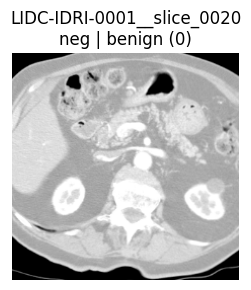

In [41]:
# Change the image_id if needed
show_processed_sample(example_ids[0], processed_df)


In [42]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

META_PATH = "out/preprocessed_xy1_crop224_target_class/processed_metadata_all_samples.csv"
df = pd.read_csv(META_PATH)

def visualize_by_id(image_id, alpha=0.4):
    row = df[df["image_id"] == image_id]
    if len(row) == 0:
        print("Image ID not found")
        return

    row = row.iloc[0]
    if not isinstance(row["image_path"], str) or len(str(row["image_path"]).strip()) == 0:
        print("This row has no saved image. processing_status =", row["processing_status"])
        return

    img = np.load(row["image_path"])
    img_vis = img.copy()
    if img_vis.max() > 1:
        img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-6)

    sample_type = row["sample_type"]

    if sample_type == "pos":
        mask_path = row["mask_path"]
        if isinstance(mask_path, str) and mask_path != "":
            mask = np.load(mask_path)
        else:
            print("Mask missing for positive sample!")
            mask = np.zeros_like(img_vis)

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.title(f"Image\n{row['target_class']} ({row['target_class_id']})")
        plt.imshow(img_vis, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Mask")
        plt.imshow(mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Overlay")
        plt.imshow(img_vis, cmap="gray")
        plt.imshow(mask, cmap="jet", alpha=alpha)
        plt.axis("off")
        plt.suptitle(f"{image_id} ({sample_type})", fontsize=14)
        plt.show()
    else:
        plt.figure(figsize=(5, 5))
        plt.title(f"{image_id}\n{sample_type} | {row['target_class']} ({row['target_class_id']})")
        plt.imshow(img_vis, cmap="gray")
        plt.axis("off")
        plt.show()


def compare_original_with_augments(base_image_id, alpha=0.4):
    rows = df[df["image_id"].astype(str).str.startswith(base_image_id)].copy()
    rows = rows[rows["processing_status"] == "ok"]
    if len(rows) == 0:
        print("Base image ID not found")
        return

    rows["is_aug"] = rows["image_id"].astype(str).str.contains("__aug_tx_", regex=False)
    rows = rows.sort_values(["is_aug", "image_id"]).reset_index(drop=True)
    print(f"Found {len(rows) - 1} newly created images for base image: {base_image_id}")
    show_original_vs_augmented(base_image_id, df, alpha=alpha)


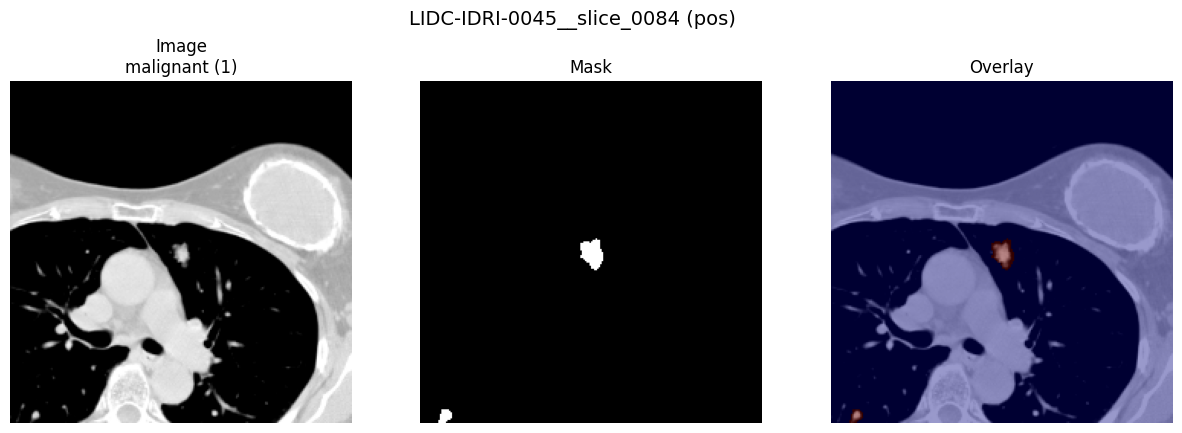

Found 2 newly created images for base image: LIDC-IDRI-0590__slice_0261


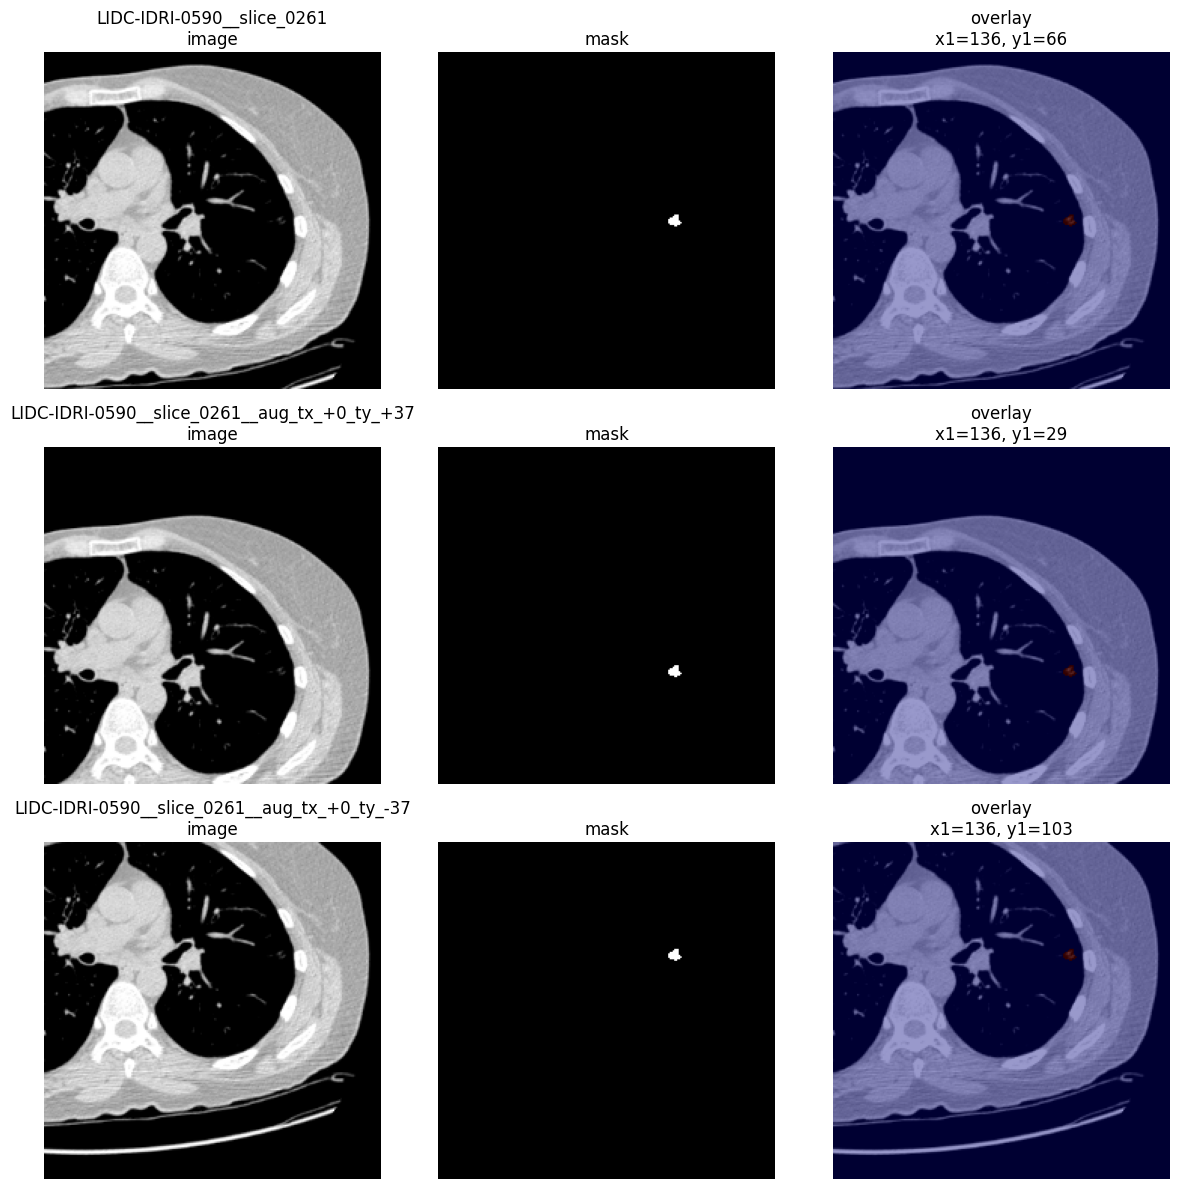

In [43]:
# Example:
visualize_by_id("LIDC-IDRI-0045__slice_0084")
compare_original_with_augments("LIDC-IDRI-0590__slice_0261")
